# Histopathologic Cancer Detection Deep Model — V4

<center>
    <h3>Utilizing deep learning to detect cancer in histopathologic images.</h3><br>
    <h5>By: Michael Hansen</h5>
    <h5>Date: 02/04/2025 (V4 revision: 05/24/2026)</h5>
    <h5>Course: DTSA5511 Deep Learning</h5>
    <h5>Instructor: Dr. Ying Sun</h5>
</center>

This notebook is an exploration into Deep Learning and its use to detect cancer in histopathologic images. The dataset provided in this Kaggle competition is a collection of histopathologic images of breast cancer tumors. The goal is to build a model that can accurately detect cancer in these images.

The importance of being able to perform this task with a deep learning model cannot be understated. For this project I use the [Keras](https://keras.io/) library to build the model, with pooling, dropout, batch normalization and L2 regularization to improve generalization.

The dataset can be found [here](https://www.kaggle.com/competitions/histopathologic-cancer-detection/data), and was originally obtained from the [TCGA](https://portal.gdc.cancer.gov/projects/TCGA-BRCA) project. There are roughly 220,000 labeled images for training and about 57,000 for the test set.

**About this revision (V4).**:

- From V3: `ImageDataGenerator` augmentation, a regularized functional VGG-style model (BN + L2 + He init + Dropout), `train_test_split`, `model.fit` with `ModelCheckpoint` / `EarlyStopping` / `CSVLogger` / `TensorBoard`, and a `CosineDecayRestarts` LR schedule.
- From the original: relative `train/` / `test/` paths, parallel image loading with `ThreadPoolExecutor` during inference, atomic per-batch writes of `submission.csv`, and global RNG seeding.
- Fixes a few V3 bugs: only one model is trained and used end-to-end, test-time preprocessing matches training (`/255` rescale), and `steps_per_epoch` is derived from `generator.samples` so no epoch runs out of data.

## 1. Setup

In [4]:
# Importing Libraries
import os
import gc
import random
import multiprocessing
from glob import glob
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, BatchNormalization, Activation,
    Conv2D, MaxPool2D, Input,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, TensorBoard, CSVLogger,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
)

In [5]:
# Reproducibility: seed Python, NumPy and TensorFlow globally.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPUs available     :', len(tf.config.list_physical_devices('GPU')))
print('GPU devices        :', tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.21.0
GPUs available     : 0
GPU devices        : []


In [6]:
# Image folders: default Kaggle unzip layout (`train/`, `test/`) next to
# this notebook. CSVs live under `Data/`.
DATA_DIR = 'Data'
train_path = 'Data/train'
test_path = 'Data/test'

labels = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
print('Example of labels')
labels.head()

Example of labels


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [7]:
# Build the training dataframe by joining file paths with labels.
train_data_frame = pd.DataFrame({
    'path': [p.replace('\\', '/') for p in glob(os.path.join(train_path, '*.tif'))]
})
train_data_frame['id'] = train_data_frame.path.map(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
df_data = train_data_frame.merge(labels, on='id')
print(f'Found {len(train_data_frame)} training images')
df_data.head()

Found 220025 training images


,path,id,label
0,Data/train/00001b2b5609af42ab0ab276dd4cd41c3e7...,00001b2b5609af42ab0ab276dd4cd41c3e7745b5,1
1,Data/train/000020de2aa6193f4c160e398a8edea95b1...,000020de2aa6193f4c160e398a8edea95b1da598,0
2,Data/train/00004aab08381d25d315384d646f5ce413e...,00004aab08381d25d315384d646f5ce413ea24b1,0
3,Data/train/0000d563d5cfafc4e68acb7c9829258a298...,0000d563d5cfafc4e68acb7c9829258a298d9b6a,0
4,Data/train/0000da768d06b879e5754c43e2298ce4872...,0000da768d06b879e5754c43e2298ce48726f722,1


In [8]:
test_data_frame = pd.DataFrame({
    'path': [p.replace('\\', '/') for p in glob(os.path.join(test_path, '*.tif'))]
})
test_data_frame['id'] = test_data_frame.path.map(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
print(f'Found {len(test_data_frame)} test images')
test_data_frame.head()

Found 57458 test images


,path,id
0,Data/test/00006537328c33e284c973d7b39d340809f7...,00006537328c33e284c973d7b39d340809f7271b
1,Data/test/0000ec92553fda4ce39889f9226ace43cae3...,0000ec92553fda4ce39889f9226ace43cae3364e
2,Data/test/00024a6dee61f12f7856b0fc6be20bc7a48b...,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2
3,Data/test/000253dfaa0be9d0d100283b22284ab2f6b6...,000253dfaa0be9d0d100283b22284ab2f6b643f6
4,Data/test/000270442cc15af719583a8172c87cd2bd9c...,000270442cc15af719583a8172c87cd2bd9c7746


## 2. Exploratory Data Analysis

Before training we want to (a) sanity-check the data we just loaded, (b) look at a few patches and the class balance, and (c) see whether there is any obviously different pixel-intensity signature between positive and negative patches.

According to the [NCBI Bookshelf entry on cancer cell morphology](https://www.ncbi.nlm.nih.gov/books/NBK9553/), cancerous cells tend to differ from healthy cells in size, shape, and color. Pairwise image comparison is infeasible at this scale, but the per-channel pixel distributions (red/green/blue + combined) give us a cheap first look.

In [9]:
def load_sample_images(data_frame, num_samples=12, seed=SEED):
    """Load a few images as RGB uint8 arrays for visualization."""
    sample_df = data_frame.sample(n=num_samples, random_state=seed)
    images, labels_out = [], []
    for _, row in sample_df.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels_out.append(row['label'])
    return np.array(images), np.array(labels_out)

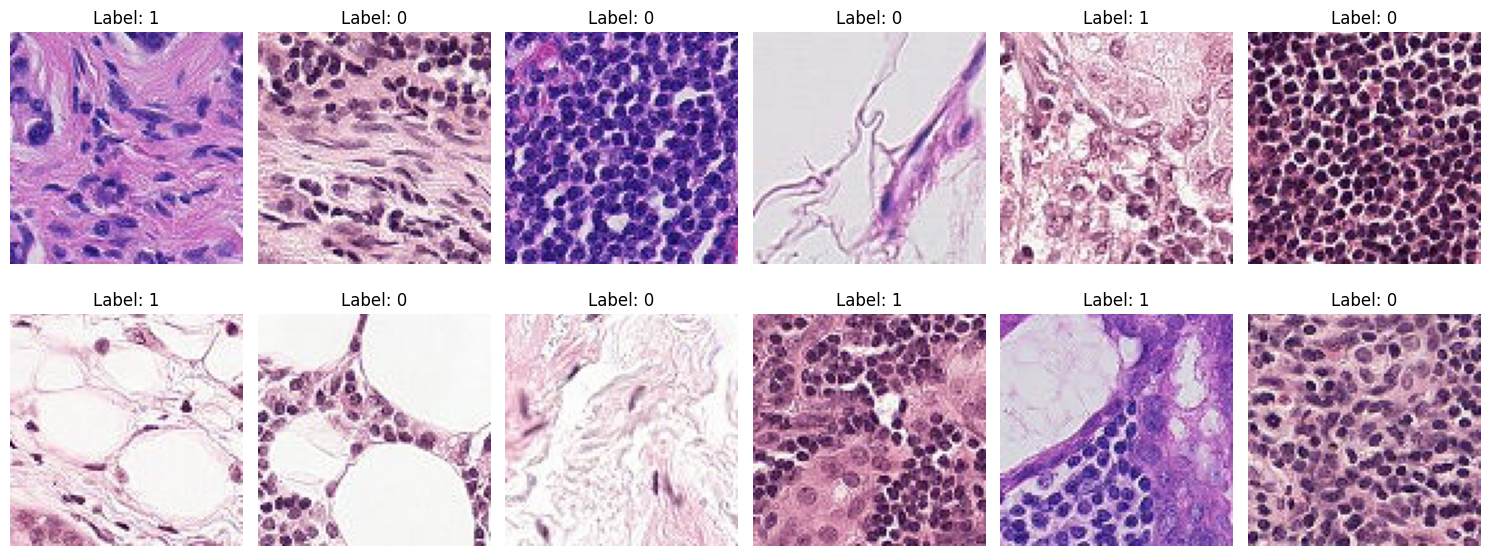


Label distribution in displayed samples:
  Label 0: 7 images
  Label 1: 5 images

Total dataset label distribution:
  Label 0: 130908 images (59.5%)
  Label 1: 89117 images (40.5%)


In [10]:
X_samples, y_samples = load_sample_images(df_data, num_samples=12)

plt.figure(figsize=(15, 6))
for plot_nr in range(len(X_samples)):
    plt.subplot(2, len(X_samples) // 2, plot_nr + 1)
    plt.imshow(X_samples[plot_nr])
    plt.title(f'Label: {y_samples[plot_nr]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

print('\nLabel distribution in displayed samples:')
unique, counts = np.unique(y_samples, return_counts=True)
for label, count in zip(unique, counts):
    print(f'  Label {label}: {count} images')

print('\nTotal dataset label distribution:')
label_counts = df_data['label'].value_counts().sort_index()
for label, count in label_counts.items():
    print(f'  Label {label}: {count} images ({count / len(df_data) * 100:.1f}%)')

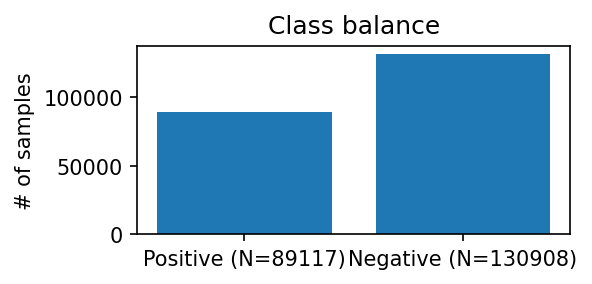

In [11]:
# Class balance plot
n_neg = int((df_data['label'] == 0).sum())
n_pos = int((df_data['label'] == 1).sum())

plt.figure(figsize=(4, 2), dpi=150)
plt.bar([1, 0], [n_neg, n_pos])
plt.xticks([1, 0], [f'Negative (N={n_neg})', f'Positive (N={n_pos})'])
plt.ylabel('# of samples')
plt.title('Class balance')
plt.tight_layout()
plt.show()

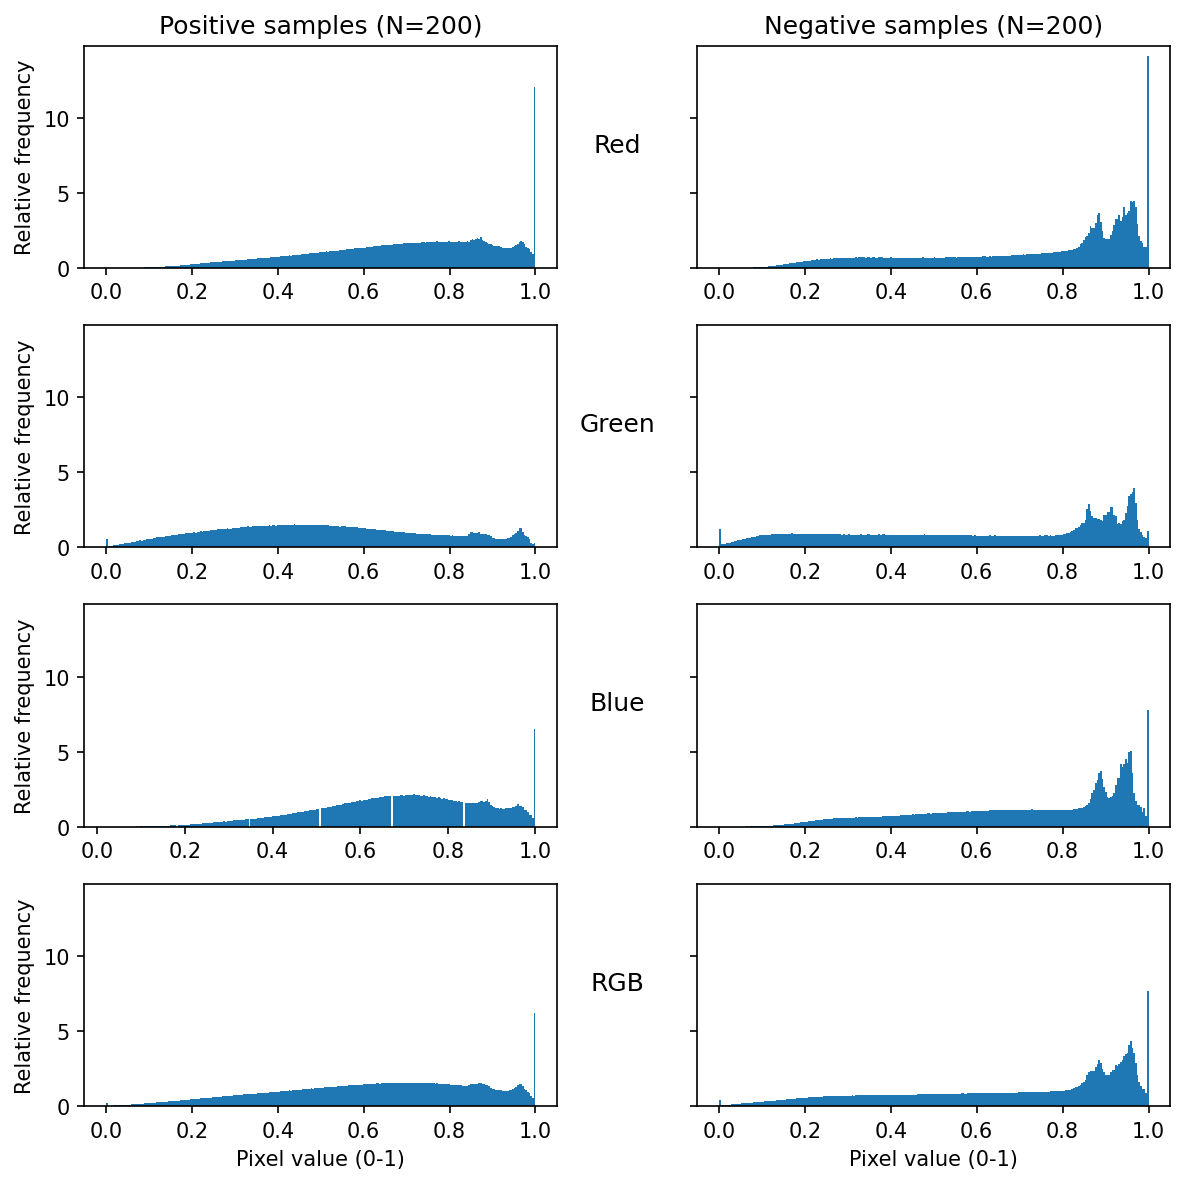

21

In [12]:
def load_batch_images(dataframe, batch_size=200, seed=SEED):
    """Load a random sample of images as RGB float arrays in [0, 1].

    Matches the training preprocessing (BGR->RGB, divide by 255) so the
    histograms below reflect what the model actually sees.
    """
    sample = dataframe.sample(n=min(batch_size, len(dataframe)), random_state=seed)
    images = []
    for _, row in sample.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
        images.append(img)
    return np.array(images)

positive_samples = df_data[df_data['label'] == 1]
negative_samples = df_data[df_data['label'] == 0]
pos_images = load_batch_images(positive_samples, batch_size=200)
neg_images = load_batch_images(negative_samples, batch_size=200)

nr_of_bins = 256
fig, axs = plt.subplots(4, 2, sharey=True, figsize=(8, 8), dpi=150)

# RGB channels
axs[0, 0].hist(pos_images[:, :, :, 0].flatten(), bins=nr_of_bins, density=True)
axs[0, 1].hist(neg_images[:, :, :, 0].flatten(), bins=nr_of_bins, density=True)
axs[1, 0].hist(pos_images[:, :, :, 1].flatten(), bins=nr_of_bins, density=True)
axs[1, 1].hist(neg_images[:, :, :, 1].flatten(), bins=nr_of_bins, density=True)
axs[2, 0].hist(pos_images[:, :, :, 2].flatten(), bins=nr_of_bins, density=True)
axs[2, 1].hist(neg_images[:, :, :, 2].flatten(), bins=nr_of_bins, density=True)
axs[3, 0].hist(pos_images.flatten(),           bins=nr_of_bins, density=True)
axs[3, 1].hist(neg_images.flatten(),           bins=nr_of_bins, density=True)

axs[0, 0].set_title(f'Positive samples (N={len(pos_images)})')
axs[0, 1].set_title(f'Negative samples (N={len(neg_images)})')
for row_idx, name in enumerate(['Red', 'Green', 'Blue', 'RGB']):
    axs[row_idx, 1].set_ylabel(name, rotation='horizontal', labelpad=35, fontsize=12)
    axs[row_idx, 0].set_ylabel('Relative frequency')
axs[3, 0].set_xlabel('Pixel value (0-1)')
axs[3, 1].set_xlabel('Pixel value (0-1)')
fig.tight_layout()
plt.show()

del pos_images, neg_images
gc.collect()

## 3. Data Preprocessing & Augmentation

Histopathology patches have no preferred orientation (the tissue can be rotated or mirrored arbitrarily under the microscope), so heavy geometric augmentation is essentially free signal. We also rescale pixel values to `[0, 1]` so the network sees the same value range we use at inference time.

In [13]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,  # safe for pathology patches
    fill_mode='nearest',
)

# Validation: only rescale, no augmentation.
validation_datagen = ImageDataGenerator(rescale=1.0 / 255)

In [14]:
batch_size = 32

# `flow_from_dataframe` expects the label column to be a string for
# class_mode='binary' so it can build the class index.
df_data_str = df_data.copy()
df_data_str['label'] = df_data_str['label'].astype(str)

X_train, X_val = train_test_split(
    df_data_str,
    test_size=0.2,
    random_state=SEED,
    stratify=df_data_str['label'],
)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)

train_generator = datagen.flow_from_dataframe(
    dataframe=X_train,
    x_col='path',
    y_col='label',
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
    seed=SEED,
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=X_val,
    x_col='path',
    y_col='label',
    target_size=(96, 96),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', train_generator.class_indices)

Found 176020 validated image filenames belonging to 2 classes.
Found 44005 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


## 4. Model Architecture

VGG-style stack: three convolutional blocks with increasing filter counts (32 → 64 → 128), each block being two 3×3 conv layers with batch normalization and ReLU, followed by max-pool and dropout. He initialization and L2 weight decay are applied to every conv and dense layer to help with generalization.

In [15]:
kernel_size = (3, 3)
pool_size = (2, 2)
first_filters = 32
second_filters = 64
third_filters = 128

dropout_conv = 0.4
dropout_dense = 0.5
l2_reg = 1e-3

def conv_bn_relu(x, filters, use_bias=False):
    x = Conv2D(
        filters,
        kernel_size,
        use_bias=use_bias,
        kernel_regularizer=l2(l2_reg),
        kernel_initializer='he_normal',
    )(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

inputs = Input(shape=(96, 96, 3))

# Conv block 1
x = conv_bn_relu(inputs, first_filters, use_bias=True)
x = conv_bn_relu(x, first_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 2
x = conv_bn_relu(x, second_filters)
x = conv_bn_relu(x, second_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Conv block 3
x = conv_bn_relu(x, third_filters)
x = conv_bn_relu(x, third_filters)
x = MaxPool2D(pool_size=pool_size)(x)
x = Dropout(dropout_conv)(x)

# Fully connected head
x = Flatten()(x)
x = Dense(256, use_bias=False, kernel_initializer='he_normal',
          kernel_regularizer=l2(l2_reg))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_dense)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=inputs, outputs=outputs, name='cancer_cnn_v4')
model.summary()

Model: "cancer_cnn_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 92, 92, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 92, 92, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 92, 92, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 44, 44, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 42, 42, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 42, 42, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 19, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 17, 17, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 2,386,817 (9.10 MB)

 Trainable params: 2,385,409 (9.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 5. Training

We use Adam with a `CosineDecayRestarts` schedule (warm restarts let the optimizer escape shallow minima), and a small standard callbacks kit: best-by-`val_accuracy` checkpointing, early stopping on `val_loss`, CSV logging, and TensorBoard.

In [16]:
checkpoint_path = 'model_checkpoints/best_model_v4.keras'
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Use generator.samples (not len(df)) so steps line up exactly with the
# data and we don't see the 'input ran out of data' warning.
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

initial_learning_rate = 1e-4
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate,
    first_decay_steps=steps_per_epoch,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-4,
)
optimizer = Adam(learning_rate=lr_schedule)

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        verbose=1,
        save_best_only=True,
        mode='max',
        save_weights_only=False,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    CSVLogger('training_history.csv'),
    TensorBoard(log_dir='./logs', histogram_freq=1),
]

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
)

np.save('training_history.npy', history.history)

Epoch 1/15
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7648 - loss: 1.7762
Epoch 1: val_accuracy improved from None to 0.78907, saving model to model_checkpoints/best_model_v4.keras

Epoch 1: finished saving model to model_checkpoints/best_model_v4.keras
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 763s 138ms/step - accuracy: 0.7950 - loss: 1.6087 - val_accuracy: 0.7891 - val_loss: 1.4701
Epoch 2/15
   1/5500 ━━━━━━━━━━━━━━━━━━━━ 10:28 114ms/step - accuracy: 0.8438 - loss: 1.3332

c:\Users\Belgarath\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.78907 to 0.79048, saving model to model_checkpoints/best_model_v4.keras

Epoch 2: finished saving model to model_checkpoints/best_model_v4.keras
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.8438 - loss: 1.3332 - val_accuracy: 0.7905 - val_loss: 1.4666
Epoch 3/15
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8181 - loss: 1.2367
Epoch 3: val_accuracy improved from 0.79048 to 0.81159, saving model to model_checkpoints/best_model_v4.keras

Epoch 3: finished saving model to model_checkpoints/best_model_v4.keras
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 736s 134ms/step - accuracy: 0.8237 - loss: 1.0758 - val_accuracy: 0.8116 - val_loss: 0.8865
Epoch 4/15
   1/5500 ━━━━━━━━━━━━━━━━━━━━ 11:49 129ms/step - accuracy: 0.7812 - loss: 0.8320
Epoch 4: val_accuracy did not improve from 0.81159
5500/5500 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.7812 - loss: 0.8320 - val_accuracy: 0.8108 - val_loss: 0.8870
Epoch 5/15
5500/5500 ━━━━━━━━━━━━━━━

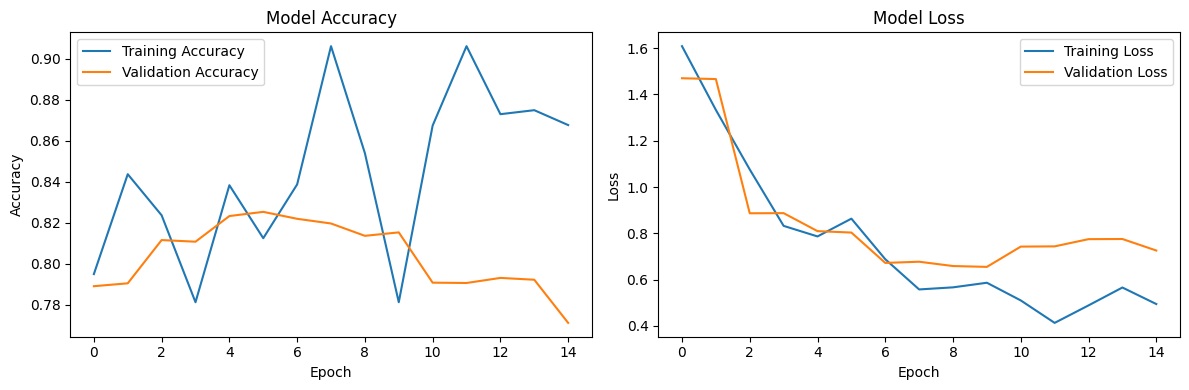

In [17]:
def plot_training_history(hist):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(hist['accuracy'], label='Training Accuracy')
    ax1.plot(hist['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(hist['loss'], label='Training Loss')
    ax2.plot(hist['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history.history)

## 6. Validation

Re-evaluate the model on the held-out validation generator and look at the full classification report, confusion matrix and ROC curve so we have more than a single accuracy number to interpret.

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.8153 - loss: 0.6548

Validation loss     : 0.6548
Validation accuracy : 0.8153
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step

Classification report:
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.84     26178
    Positive       0.77      0.78      0.77     17822

    accuracy                           0.82     44000
   macro avg       0.81      0.81      0.81     44000
weighted avg       0.82      0.82      0.82     44000



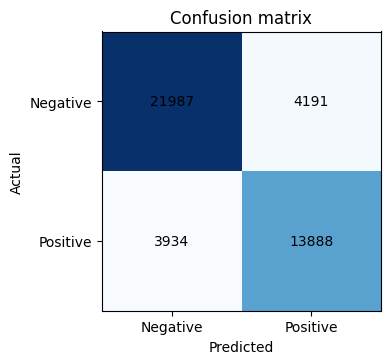

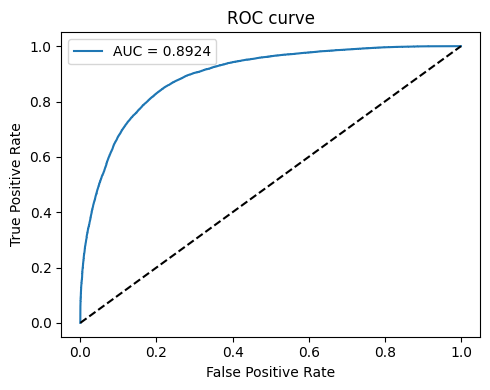

In [18]:
val_loss, val_accuracy = model.evaluate(
    validation_generator, steps=validation_steps, verbose=1
)
print(f'\nValidation loss     : {val_loss:.4f}')
print(f'Validation accuracy : {val_accuracy:.4f}')

# Reset the generator so predictions line up with .classes ordering.
validation_generator.reset()
val_pred_prob = model.predict(
    validation_generator, steps=validation_steps, verbose=1
).flatten()
val_true = validation_generator.classes[: len(val_pred_prob)]
val_pred = (val_pred_prob >= 0.5).astype(int)

print('\nClassification report:')
print(classification_report(
    val_true, val_pred, target_names=['Negative', 'Positive']
))

# Confusion matrix
cm = confusion_matrix(val_true, val_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap='Blues')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(val_true, val_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Kaggle Submission

Generate predictions for the test set and write `Data/submission.csv`.

Two things to note vs. V3:

1. **Same preprocessing as training**: BGR→RGB **and** `/255` rescale.
   V3 forgot the rescale, so its test inputs were in `[0, 255]` while    the model was trained on `[0, 1]`.
2. **Parallel I/O + atomic writes**: like the original, we use    `ThreadPoolExecutor` to read TIFs in parallel and re-write the CSV    after every batch, so a crash partway through doesn't lose work.

In [19]:
def process_test_image(path):
    """Read a test image with the same preprocessing as training.

    Returns a float32 RGB array in [0, 1], or None on failure.
    """
    img = cv2.imread(path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype('float32') / 255.0
    return img

os.makedirs(DATA_DIR, exist_ok=True)
submission_path = os.path.join(DATA_DIR, 'submission.csv')
print(submission_path)
target_size = (96, 96)
file_batch = 500
num_workers = max(1, multiprocessing.cpu_count() - 2)
max_idx = len(test_data_frame)

submission = pd.DataFrame()

for idx in tqdm(range(0, max_idx, file_batch),
                desc='Processing test batches', unit='batch'):
    batch_df = test_data_frame.iloc[idx:idx + file_batch].copy()
    paths = batch_df['path'].tolist()

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process_test_image, paths))

    valid_imgs, valid_idx = [], []
    for i, img in enumerate(results):
        if img is not None and img.shape == (*target_size, 3):
            valid_imgs.append(img)
            valid_idx.append(i)
        else:
            shape = None if img is None else img.shape
            print(f'Skipping {paths[i]} (shape={shape})')

    if not valid_imgs:
        continue

    K_test = np.stack(valid_imgs)
    preds = model.predict(K_test, verbose=0).flatten()

    batch_out = batch_df.iloc[valid_idx].copy()
    batch_out['label'] = preds

    submission = pd.concat([submission, batch_out[['id', 'label']]])
    # Atomic-ish snapshot after every batch so a crash mid-loop doesn't
    # lose all of the predictions computed so far.
    submission.to_csv(submission_path, index=False, header=True)

print(f'\nWrote {len(submission)} predictions to {submission_path}')
submission.head()

Data\submission.csv


Processing test batches: 100%|██████████| 115/115 [01:02<00:00,  1.84batch/s]


Wrote 57458 predictions to Data\submission.csv


,id,label
0,00006537328c33e284c973d7b39d340809f7271b,0.905844
1,0000ec92553fda4ce39889f9226ace43cae3364e,0.782174
2,00024a6dee61f12f7856b0fc6be20bc7a48ba3d2,0.444554
3,000253dfaa0be9d0d100283b22284ab2f6b643f6,0.595605
4,000270442cc15af719583a8172c87cd2bd9c7746,0.035839
